**Refugee Dataset OC Segmentation Without PVBM**

**Cell 1: Import Libraries**

In [1]:
import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

**Cell 2: Get ROI and OC mask**

In [2]:
def get_roi_and_oc_mask(image, combined_mask, output_size=(256,256)):
    if len(combined_mask.shape) == 3:
        combined_mask = cv2.cvtColor(
            combined_mask,
            cv2.COLOR_BGR2GRAY
        )

    od_mask = (combined_mask < 255).astype(np.uint8) * 255

    masked_img = cv2.bitwise_and(image,image,mask=od_mask)
    # plt.imshow(combined_mask)

    ys, xs = np.where(od_mask > 0)

    ymin = ys.min()
    ymax = ys.max()

    xmin = xs.min()
    xmax = xs.max()
    
    img_crop = masked_img[ymin:ymax+1,xmin:xmax+1]
    mask_crop = combined_mask[ymin:ymax+1,xmin:xmax+1]
    oc_mask = (mask_crop == 0).astype(np.uint8) * 255

    # plt.imshow(img_crop)

    # apply cropping if needed, not necessarily for training purposes
    gray = cv2.cvtColor(
        img_crop,
        cv2.COLOR_BGR2GRAY
    )
    valid = gray > 7
    rows = valid.any(1)
    cols = valid.any(0)
    ymin = np.where(rows)[0][0]
    ymax = np.where(rows)[0][-1]
    xmin = np.where(cols)[0][0]
    xmax = np.where(cols)[0][-1]
    
    # img_crop = img_crop[
    #     ymin:ymax+1,
    #     xmin:xmax+1
    # ]

    # oc_mask = oc_mask[
    #     ymin:ymax+1,
    #     xmin:xmax+1
    # ]

    img_crop = cv2.resize(img_crop,output_size)
    oc_mask = cv2.resize(oc_mask,output_size,interpolation=cv2.INTER_NEAREST)

    return img_crop, oc_mask

**Cell 3: Test on a single REFUGE2 image**

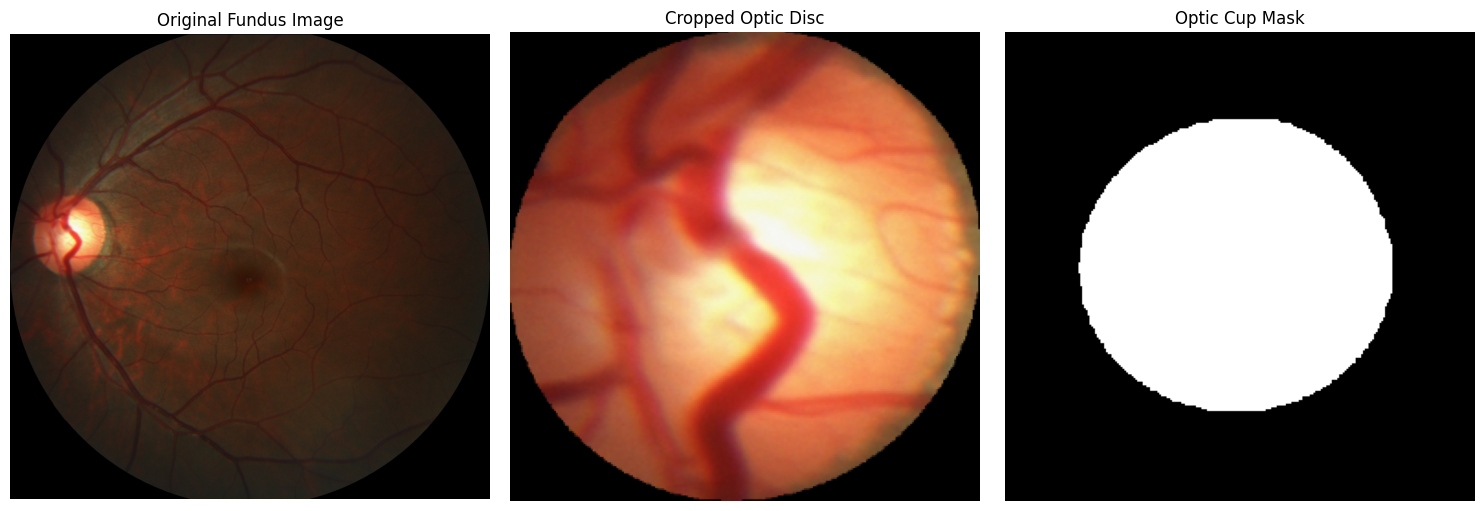

Cropped Image shape: (256, 256, 3)
Cup Mask shape: (256, 256)
Cup unique values: [  0 255]
Cup area: 21471 pixels


In [4]:
test_image_path = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/images/g0001.jpg'
test_mask_path = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/mask/g0001.bmp'

# Read image and mask
image = cv2.imread(test_image_path)
combined_mask = cv2.imread(test_mask_path, cv2.IMREAD_GRAYSCALE)

cropped_image, cup_mask = get_roi_and_oc_mask(image, combined_mask)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title('Original Fundus Image')
axes[0].axis('off')

# Cropped Optic Disc
cropped_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
axes[1].imshow(cropped_rgb)
axes[1].set_title('Cropped Optic Disc')
axes[1].axis('off')

# Cup Mask
axes[2].imshow(cup_mask, cmap='gray')
axes[2].set_title('Optic Cup Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Cropped Image shape: {cropped_image.shape}")
print(f"Cup Mask shape: {cup_mask.shape}")
print(f"Cup unique values: {np.unique(cup_mask)}")
print(f"Cup area: {np.sum(cup_mask > 0)} pixels")

**Cell 4: Batch Processing for all images**

In [5]:
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/REFUGE2_Processed'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

splits = ['train', 'val', 'test']
stats = {}

print("="*60)
print("PROCESSING REFUGE2 DATASET")
print("="*60)

for split in splits:
    images_dir = os.path.join(INPUT_PATH, split, 'images')
    masks_dir = os.path.join(INPUT_PATH, split, 'mask')
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {split}")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, split, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, split, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    
    print(f"\n📁 {split} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Find corresponding mask
            mask_file = None
            for ext in ['.bmp', '.png', '.jpg', '.jpeg']:
                potential = os.path.join(masks_dir, f"{img_name}{ext}")
                if os.path.exists(potential):
                    mask_file = potential
                    break
            
            if mask_file is None:
                continue
            
            # Read image and mask
            image = cv2.imread(img_path)
            combined_mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
            
            # Apply sir's function
            cropped_image, cup_mask = get_roi_and_oc_mask(image, combined_mask)
            
            # Save cropped image (BGR format)
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            # Save cup mask
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cup_mask)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[split] = success
    print(f"  ✅ {split}: {success} images")

# Create ZIP
zip_path = '/kaggle/working/REFUGE2_OC_Seg_WP.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING REFUGE2 DATASET

📁 train - 400 images


100%|██████████| 400/400 [01:03<00:00,  6.27it/s]


  ✅ train: 400 images

📁 val - 400 images


100%|██████████| 400/400 [00:41<00:00,  9.59it/s]


  ✅ val: 400 images

📁 test - 400 images


100%|██████████| 400/400 [00:38<00:00, 10.28it/s]


  ✅ test: 400 images

✅ ZIP created: /kaggle/working/REFUGE2_OC_Seg_WP.zip
📊 Size: 20.18 MB


/kaggle/working/REFUGE2_OC_Seg_WP.zip

**DRISHTI-GS DATASET**

**Cell 1: Import libraries**

In [6]:
import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

**Cell 2: Modified Function for Drishti GS**

In [11]:
def get_roi_and_oc_mask_drishti(image, od_mask, oc_mask, output_size=(256,256)):
    """
    Modified version of sir's function for Drishti GS
    """
    
    # Step 1: Ensure masks are grayscale
    if len(od_mask.shape) == 3:
        od_mask = cv2.cvtColor(od_mask, cv2.COLOR_BGR2GRAY)
    if len(oc_mask.shape) == 3:
        oc_mask = cv2.cvtColor(oc_mask, cv2.COLOR_BGR2GRAY)
    
    # Step 2: Use same logic as code - od_mask = all non-zero pixels in disc mask
    od_region = (od_mask > 0).astype(np.uint8) * 255
    
    # Masked image (only disc region) - NO GLOW, using original image
    masked_img = cv2.bitwise_and(image, image, mask=od_region)
    
    # Step 3: Get bounding box from disc mask
    ys, xs = np.where(od_region > 0)
    
    if len(ys) == 0 or len(xs) == 0:
        ymin, ymax = 0, image.shape[0] - 1
        xmin, xmax = 0, image.shape[1] - 1
    else:
        ymin = ys.min()
        ymax = ys.max()
        xmin = xs.min()
        xmax = xs.max()
    
    # Step 4: Crop image and masks
    img_crop = masked_img[ymin:ymax+1, xmin:xmax+1]
    od_crop = od_mask[ymin:ymax+1, xmin:xmax+1]
    oc_crop = oc_mask[ymin:ymax+1, xmin:xmax+1]
    
    # Step 5: Create cup mask (same logic: cup = pixels that are cup in ground truth)
    cup_mask = (oc_crop > 0).astype(np.uint8) * 255
    
    # Step 6: Remove black borders
    gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    valid = gray > 7
    rows = valid.any(1)
    cols = valid.any(0)
    
    if rows.any() and cols.any():
        ymin_border = np.where(rows)[0][0]
        ymax_border = np.where(rows)[0][-1]
        xmin_border = np.where(cols)[0][0]
        xmax_border = np.where(cols)[0][-1]
        
        img_crop = img_crop[ymin_border:ymax_border+1, xmin_border:xmax_border+1]
        cup_mask = cup_mask[ymin_border:ymax_border+1, xmin_border:xmax_border+1]
    
    # Step 7: Resize to output size
    img_crop = cv2.resize(img_crop, output_size)
    cup_mask = cv2.resize(cup_mask, output_size, interpolation=cv2.INTER_NEAREST)
    
    return img_crop, cup_mask

**Cell 3: Test on Single Image**

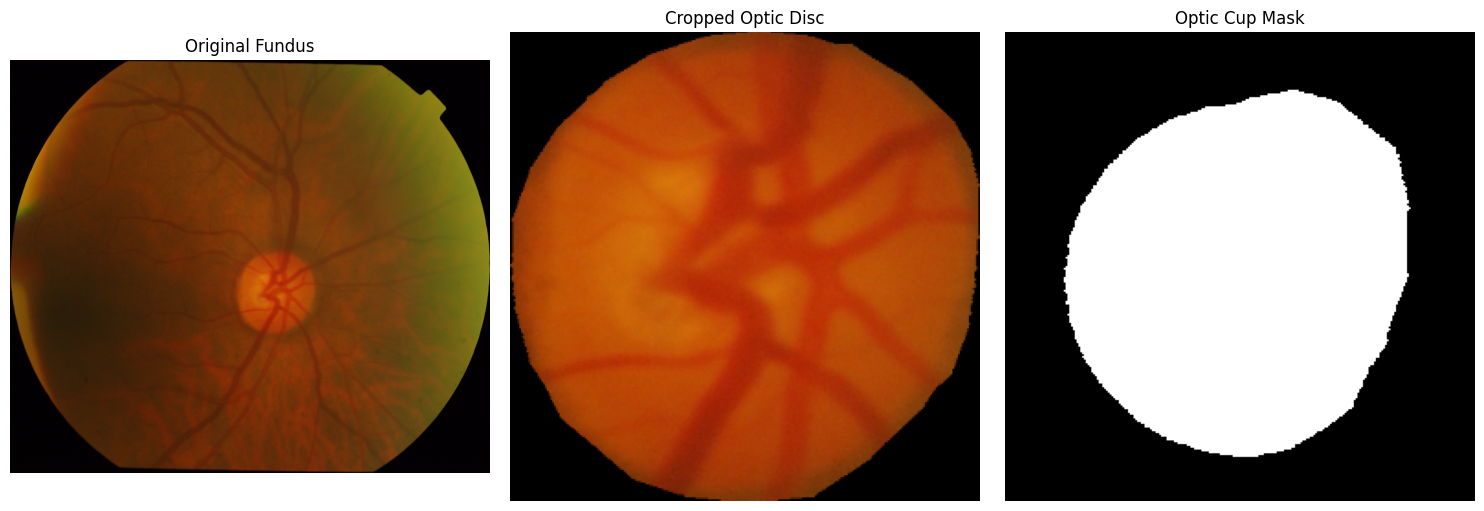

Cropped Image shape: (256, 256, 3)
Cup Mask shape: (256, 256)
Cup unique values: [  0 255]
Cup area: 29027 pixels


In [15]:
test_image_path = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/Images/GLAUCOMA/drishtiGS_038.png'
test_od_path = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_038/SoftMap/drishtiGS_038_ODsegSoftmap.png'
test_oc_path = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_038/SoftMap/drishtiGS_038_cupsegSoftmap.png'

# Read image and masks
image = cv2.imread(test_image_path)
od_mask = cv2.imread(test_od_path, cv2.IMREAD_GRAYSCALE)
oc_mask = cv2.imread(test_oc_path, cv2.IMREAD_GRAYSCALE)

# Step 1: Resize all to same size if needed
image, od_mask, oc_mask = resize_to_match(image, od_mask, oc_mask)

# Step 2: Apply the function
cropped_image, cup_mask = get_roi_and_oc_mask_drishti(image, od_mask, oc_mask)

# Display results (only 3 images now)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title('Original Fundus')
axes[0].axis('off')

# Cropped image
cropped_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
axes[1].imshow(cropped_rgb)
axes[1].set_title('Cropped Optic Disc')
axes[1].axis('off')

# Cup mask
axes[2].imshow(cup_mask, cmap='gray')
axes[2].set_title('Optic Cup Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Cropped Image shape: {cropped_image.shape}")
print(f"Cup Mask shape: {cup_mask.shape}")
print(f"Cup unique values: {np.unique(cup_mask)}")
print(f"Cup area: {np.sum(cup_mask > 0)} pixels")

**Cell 4: Batch Processing for all images**

In [19]:
# Batch process all Drishti GS images
INPUT_PATH = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation'
OUTPUT_PATH = '/kaggle/working/DRISHTI_GS_Processed'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

stats = {}

print("="*60)
print("PROCESSING DRISHTI GS DATASET")
print("="*60)

# Process Training
print("\n📁 Processing TRAINING")
main_folder = 'Training-20211018T055246Z-001'
sub_folder = 'Training'
categories = ['GLAUCOMA', 'NORMAL']

for category in categories:
    images_dir = os.path.join(INPUT_PATH, main_folder, sub_folder, 'Images', category)
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping Training/{category} - images not found")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, 'Training', category, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, 'Training', category, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    
    print(f"\n📁 Training/{category} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Mask paths for Training
            gt_base = os.path.join(INPUT_PATH, main_folder, sub_folder, 'GT')
            od_mask_path = os.path.join(gt_base, img_name, 'SoftMap', f"{img_name}_ODsegSoftmap.png")
            oc_mask_path = os.path.join(gt_base, img_name, 'SoftMap', f"{img_name}_cupsegSoftmap.png")
            
            if not os.path.exists(od_mask_path):
                print(f"  Missing OD mask: {od_mask_path}")
                continue
            if not os.path.exists(oc_mask_path):
                print(f"  Missing OC mask: {oc_mask_path}")
                continue
            
            # Read image and masks
            image = cv2.imread(img_path)
            od_mask = cv2.imread(od_mask_path, cv2.IMREAD_GRAYSCALE)
            oc_mask = cv2.imread(oc_mask_path, cv2.IMREAD_GRAYSCALE)
            
            if image is None:
                print(f"  Failed to read image: {img_path}")
                continue
            if od_mask is None:
                print(f"  Failed to read OD mask: {od_mask_path}")
                continue
            if oc_mask is None:
                print(f"  Failed to read OC mask: {oc_mask_path}")
                continue
            
            # Resize all to same size
            image, od_mask, oc_mask = resize_to_match(image, od_mask, oc_mask)
            
            # Apply function
            cropped_image, cup_mask = get_roi_and_oc_mask_drishti(image, od_mask, oc_mask)
            
            # Save
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cup_mask)
            
            success += 1
            
        except Exception as e:
            print(f"  Error processing {img_name}: {e}")
            continue
    
    stats[f"Training/{category}"] = success
    print(f"  ✅ {success}/{len(image_files)} images processed")

# Process Test
print("\n📁 Processing TEST")
main_folder = 'Test-20211018T060000Z-001'
sub_folder = 'Test'
categories = ['glaucoma', 'normal']

for category in categories:
    images_dir = os.path.join(INPUT_PATH, main_folder, sub_folder, 'Images', category)
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping Test/{category} - images not found")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, 'Test', category, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, 'Test', category, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    
    print(f"\n📁 Test/{category} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Mask paths for Test (Test_GT instead of GT)
            gt_base = os.path.join(INPUT_PATH, main_folder, sub_folder, 'Test_GT')
            od_mask_path = os.path.join(gt_base, img_name, 'SoftMap', f"{img_name}_ODsegSoftmap.png")
            oc_mask_path = os.path.join(gt_base, img_name, 'SoftMap', f"{img_name}_cupsegSoftmap.png")
            
            if not os.path.exists(od_mask_path):
                print(f"  Missing OD mask: {od_mask_path}")
                continue
            if not os.path.exists(oc_mask_path):
                print(f"  Missing OC mask: {oc_mask_path}")
                continue
            
            # Read image and masks
            image = cv2.imread(img_path)
            od_mask = cv2.imread(od_mask_path, cv2.IMREAD_GRAYSCALE)
            oc_mask = cv2.imread(oc_mask_path, cv2.IMREAD_GRAYSCALE)
            
            if image is None:
                print(f"  Failed to read image: {img_path}")
                continue
            if od_mask is None:
                print(f"  Failed to read OD mask: {od_mask_path}")
                continue
            if oc_mask is None:
                print(f"  Failed to read OC mask: {oc_mask_path}")
                continue
            
            # Resize all to same size
            image, od_mask, oc_mask = resize_to_match(image, od_mask, oc_mask)
            
            # Apply function
            cropped_image, cup_mask = get_roi_and_oc_mask_drishti(image, od_mask, oc_mask)
            
            # Save
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cup_mask)
            
            success += 1
            
        except Exception as e:
            print(f"  Error processing {img_name}: {e}")
            continue
    
    stats[f"Test/{category}"] = success
    print(f"  ✅ {success}/{len(image_files)} images processed")

# Create ZIP file
zip_path = '/kaggle/working/DRISHTI_GS_OC_Seg_WP.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
for key, value in stats.items():
    print(f"  {key}: {value} images")
print(f"\nTotal: {sum(stats.values())} images")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING DRISHTI GS DATASET

📁 Processing TRAINING

📁 Training/GLAUCOMA - 32 images


100%|██████████| 32/32 [00:05<00:00,  5.77it/s]


  ✅ 32/32 images processed

📁 Training/NORMAL - 18 images


100%|██████████| 18/18 [00:03<00:00,  5.90it/s]


  ✅ 18/18 images processed

📁 Processing TEST

📁 Test/glaucoma - 38 images


100%|██████████| 38/38 [00:07<00:00,  5.37it/s]


  ✅ 38/38 images processed

📁 Test/normal - 13 images


100%|██████████| 13/13 [00:02<00:00,  5.38it/s]


  ✅ 13/13 images processed

✅ ZIP created: /kaggle/working/DRISHTI_GS_OC_Seg_WP.zip
📊 Size: 1.71 MB

FINAL SUMMARY
  Training/GLAUCOMA: 32 images
  Training/NORMAL: 18 images
  Test/glaucoma: 38 images
  Test/normal: 13 images

Total: 101 images


/kaggle/working/DRISHTI_GS_OC_Seg_WP.zip

**CHAKSHU TEST DATASET**

**Cell 1: Import libraries**

In [5]:
import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

**Cell 2: Get ROI and OC mask**

In [27]:
def resize_to_match(image, mask):
    """
    Resize image and mask to same dimensions
    """
    h, w = image.shape[:2]
    h_mask, w_mask = mask.shape[:2]
    
    target_h = max(h, h_mask)
    target_w = max(w, w_mask)
    
    if (h, w) != (target_h, target_w):
        image = cv2.resize(image, (target_w, target_h))
    if (h_mask, w_mask) != (target_h, target_w):
        mask = cv2.resize(mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    return image, mask

def get_roi_and_oc_mask_chakshu(image, combined_disc_mask, combined_cup_mask, output_size=(256,256)):
    """
    Crop using disc mask (full disc), then extract cup mask using cup mask only
    """
    # Step 1: Ensure masks are grayscale
    if len(combined_disc_mask.shape) == 3:
        combined_disc_mask = cv2.cvtColor(combined_disc_mask, cv2.COLOR_BGR2GRAY)
    if len(combined_cup_mask.shape) == 3:
        combined_cup_mask = cv2.cvtColor(combined_cup_mask, cv2.COLOR_BGR2GRAY)
    
    # Step 2: Optic disc = all non-zero pixels in disc mask
    od_region = (combined_disc_mask > 0).astype(np.uint8) * 255
    
    # Masked image (only disc region)
    masked_img = cv2.bitwise_and(image, image, mask=od_region)
    
    # Step 3: Get bounding box from disc mask (full disc)
    ys, xs = np.where(od_region > 0)
    
    if len(ys) == 0 or len(xs) == 0:
        ymin, ymax = 0, image.shape[0] - 1
        xmin, xmax = 0, image.shape[1] - 1
    else:
        ymin = ys.min()
        ymax = ys.max()
        xmin = xs.min()
        xmax = xs.max()
    
    # Step 4: Crop image using disc bounding box (full disc)
    img_crop = masked_img[ymin:ymax+1, xmin:xmax+1]
    
    # Step 5: Crop cup mask using SAME disc bounding box
    cup_crop = combined_cup_mask[ymin:ymax+1, xmin:xmax+1]
    
    # Step 6: Cup mask is already binary (cup = white)
    cup_mask = (cup_crop > 0).astype(np.uint8) * 255
    
    # Step 7: Remove black borders from cropped disc
    gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    valid = gray > 7
    rows = valid.any(1)
    cols = valid.any(0)
    
    if rows.any() and cols.any():
        ymin_border = np.where(rows)[0][0]
        ymax_border = np.where(rows)[0][-1]
        xmin_border = np.where(cols)[0][0]
        xmax_border = np.where(cols)[0][-1]
        
        img_crop = img_crop[ymin_border:ymax_border+1, xmin_border:xmax_border+1]
        cup_mask = cup_mask[ymin_border:ymax_border+1, xmin_border:xmax_border+1]
    
    # Step 8: Resize to output size
    img_crop = cv2.resize(img_crop, output_size)
    cup_mask = cv2.resize(cup_mask, output_size, interpolation=cv2.INTER_NEAREST)
    
    return img_crop, cup_mask

def combine_expert_masks(image_name, camera, experts, base_path):
    """
    Combine 5 expert masks using MAJORITY VOTING (at least 3 experts agree)
    Returns disc mask and cup mask separately
    """
    expert_disc_masks = []
    expert_cup_masks = []
    
    for expert in experts:
        mask_path = os.path.join(base_path, '4.0_OD_CO_Fusion_Images', expert, camera, f"{image_name}.tif")
        
        if not os.path.exists(mask_path):
            for ext in ['.jpg', '.png', '.bmp']:
                alt_path = os.path.join(base_path, '4.0_OD_CO_Fusion_Images', expert, camera, f"{image_name}{ext}")
                if os.path.exists(alt_path):
                    mask_path = alt_path
                    break
        
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                # Disc mask: ALL non-zero pixels (values > 0) - includes both disc and cup
                disc_mask = (mask > 0).astype(np.uint8)
                expert_disc_masks.append(disc_mask)
                
                # Cup mask: ONLY white pixels (value = 255) - the small inner circle
                cup_mask = (mask == 255).astype(np.uint8)
                expert_cup_masks.append(cup_mask)
    
    if len(expert_disc_masks) != 5 or len(expert_cup_masks) != 5:
        return None, None
    
    # MAJORITY VOTING for disc: pixel = 1 if at least 3 experts agree
    disc_sum = np.sum(expert_disc_masks, axis=0)
    final_disc_mask = (disc_sum >= 3).astype(np.uint8)
    
    # MAJORITY VOTING for cup: pixel = 1 if at least 3 experts agree
    cup_sum = np.sum(expert_cup_masks, axis=0)
    final_cup_mask = (cup_sum >= 3).astype(np.uint8)
    
    # Convert to 0-255
    final_disc_mask_255 = final_disc_mask * 255
    final_cup_mask_255 = final_cup_mask * 255
    
    return final_disc_mask_255, final_cup_mask_255


**Cell 3: Test on Single Chakshu Image**

Found image: /kaggle/input/datasets/mrunal0501/chakshu-test/Test/1.0_Original_Fundus_Images/Forus/100.png
✅ Image exists: /kaggle/input/datasets/mrunal0501/chakshu-test/Test/1.0_Original_Fundus_Images/Forus/100.png


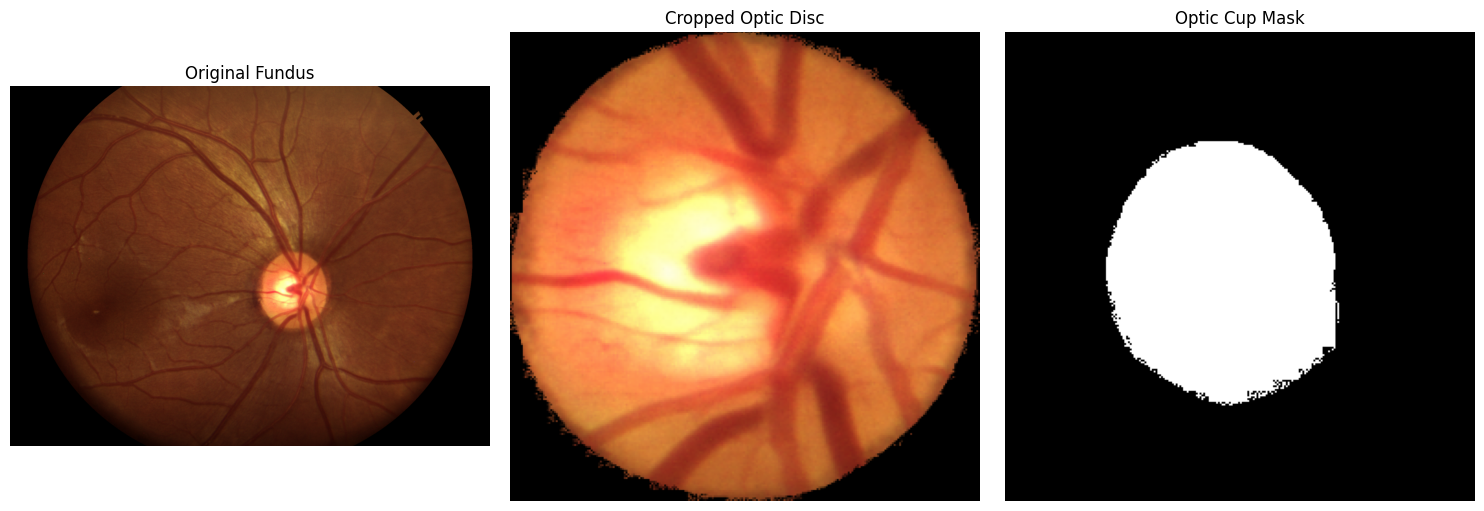

Cropped Image shape: (256, 256, 3)
Cup Mask shape: (256, 256)
Cup unique values: [  0 255]
Cup area: 13998 pixels


In [32]:
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu-test/Test'
test_camera = 'Forus'
test_image_name = '100'

# Auto-detect image extension
test_image_path = None
for ext in ['.JPG', '.jpg', '.png', '.tif', '.bmp', '.jpeg']:
    potential_path = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images', test_camera, f"{test_image_name}{ext}")
    if os.path.exists(potential_path):
        test_image_path = potential_path
        print(f"Found image: {test_image_path}")
        break

if test_image_path is None:
    print(f"❌ Image not found: {test_image_name} in {test_camera}")
else:
    print(f"✅ Image exists: {test_image_path}")

    # Combine 5 expert masks (returns disc mask and cup mask separately)
    experts = ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Expert 5']
    combined_disc_mask, combined_cup_mask = combine_expert_masks(test_image_name, test_camera, experts, INPUT_PATH)

    if combined_disc_mask is not None and combined_cup_mask is not None:
        # Read image
        image = cv2.imread(test_image_path)
        
        if image is not None:
            # Resize to match
            image, combined_disc_mask = resize_to_match(image, combined_disc_mask)
            _, combined_cup_mask = resize_to_match(image, combined_cup_mask)
            
            # Apply function
            cropped_image, cup_mask = get_roi_and_oc_mask_chakshu(image, combined_disc_mask, combined_cup_mask)
            
            # Display results
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original
            original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            axes[0].imshow(original_rgb)
            axes[0].set_title('Original Fundus')
            axes[0].axis('off')
            
            # Cropped image
            cropped_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
            axes[1].imshow(cropped_rgb)
            axes[1].set_title('Cropped Optic Disc')
            axes[1].axis('off')
            
            # Cup mask
            axes[2].imshow(cup_mask, cmap='gray')
            axes[2].set_title('Optic Cup Mask')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print(f"Cropped Image shape: {cropped_image.shape}")
            print(f"Cup Mask shape: {cup_mask.shape}")
            print(f"Cup unique values: {np.unique(cup_mask)}")
            print(f"Cup area: {np.sum(cup_mask > 0)} pixels")
        else:
            print(f"Failed to read image: {test_image_path}")
    else:
        print("Failed to combine expert masks")

**Cell 4: Batch Processing for all images**

In [33]:
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu-test/Test'
OUTPUT_PATH = '/kaggle/working/CHAKSHU_Processed'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Create fundus and masks subfolders
fundus_output = os.path.join(OUTPUT_PATH, 'fundus')
masks_output = os.path.join(OUTPUT_PATH, 'masks')
os.makedirs(fundus_output, exist_ok=True)
os.makedirs(masks_output, exist_ok=True)

# Cameras and experts
cameras = ['Bosch', 'Forus', 'Remidio']
experts = ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Expert 5']

stats = {}

print("="*60)
print("PROCESSING CHAKSHU DATASET")
print("="*60)

for camera in cameras:
    images_dir = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images', camera)
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {camera} - images not found")
        continue
    
    # Get all images (auto-detect extensions)
    image_files = []
    for f in os.listdir(images_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif')):
            image_files.append(f)
    
    print(f"\n📁 Processing {camera} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Combine 5 expert masks
            combined_disc_mask, combined_cup_mask = combine_expert_masks(img_name, camera, experts, INPUT_PATH)
            
            if combined_disc_mask is None or combined_cup_mask is None:
                continue
            
            # Read image
            image = cv2.imread(img_path)
            
            if image is None:
                continue
            
            # Resize to match
            image, combined_disc_mask = resize_to_match(image, combined_disc_mask)
            _, combined_cup_mask = resize_to_match(image, combined_cup_mask)
            
            # Apply function
            cropped_image, cup_mask = get_roi_and_oc_mask_chakshu(image, combined_disc_mask, combined_cup_mask)
            
            # Save to fundus folder (all cropped discs go here)
            output_img_path = os.path.join(fundus_output, f"{camera}_{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            # Save to masks folder (all cup masks go here)
            output_mask_path = os.path.join(masks_output, f"{camera}_{img_name}.png")
            cv2.imwrite(output_mask_path, cup_mask)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[camera] = success
    print(f"  ✅ {camera}: {success} images")

# Create ZIP file
zip_path = '/kaggle/working/CHAKSHU_OC_Seg_WP.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

print("\n📁 Output Structure:")
print("  CHAKSHU_Processed/")
print("    ├── fundus/  (all cropped optic discs)")
print("    └── masks/   (all cup masks)")

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
for camera, count in stats.items():
    print(f"  ✅ {camera}: {count} images processed")
print(f"\nTotal: {sum(stats.values())} images")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING CHAKSHU DATASET

📁 Processing Bosch - 41 images


100%|██████████| 41/41 [00:10<00:00,  3.79it/s]


  ✅ Bosch: 41 images

📁 Processing Forus - 31 images


100%|██████████| 31/31 [00:10<00:00,  3.06it/s]


  ✅ Forus: 31 images

📁 Processing Remidio - 264 images


100%|██████████| 264/264 [02:54<00:00,  1.51it/s]


  ✅ Remidio: 264 images

✅ ZIP created: /kaggle/working/CHAKSHU_OC_Seg_WP.zip
📊 Size: 5.66 MB

📁 Output Structure:
  CHAKSHU_Processed/
    ├── fundus/  (all cropped optic discs)
    └── masks/   (all cup masks)

FINAL SUMMARY
  ✅ Bosch: 41 images processed
  ✅ Forus: 31 images processed
  ✅ Remidio: 264 images processed

Total: 336 images


/kaggle/working/CHAKSHU_OC_Seg_WP.zip

**CHAKSHU TRAIN DATASET**

**Cell 1: Import Libraries**

In [1]:
import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

**Cell 2: Get ROI and OC mask**

In [11]:
def resize_to_match(image, mask):
    """
    Resize image and mask to same dimensions
    """
    h, w = image.shape[:2]
    h_mask, w_mask = mask.shape[:2]
    
    target_h = max(h, h_mask)
    target_w = max(w, w_mask)
    
    if (h, w) != (target_h, target_w):
        image = cv2.resize(image, (target_w, target_h))
    if (h_mask, w_mask) != (target_h, target_w):
        mask = cv2.resize(mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    return image, mask

def get_roi_and_oc_mask_chakshu(image, combined_disc_mask, combined_cup_mask, output_size=(256,256)):
    """
    Crop using disc mask (full disc), then extract cup mask using cup mask only
    """
    # Step 1: Ensure masks are grayscale
    if len(combined_disc_mask.shape) == 3:
        combined_disc_mask = cv2.cvtColor(combined_disc_mask, cv2.COLOR_BGR2GRAY)
    if len(combined_cup_mask.shape) == 3:
        combined_cup_mask = cv2.cvtColor(combined_cup_mask, cv2.COLOR_BGR2GRAY)
    
    # Step 2: Optic disc = all non-zero pixels in disc mask
    od_region = (combined_disc_mask > 0).astype(np.uint8) * 255
    
    # Masked image (only disc region)
    masked_img = cv2.bitwise_and(image, image, mask=od_region)
    
    # Step 3: Get bounding box from disc mask (full disc)
    ys, xs = np.where(od_region > 0)
    
    if len(ys) == 0 or len(xs) == 0:
        ymin, ymax = 0, image.shape[0] - 1
        xmin, xmax = 0, image.shape[1] - 1
    else:
        ymin = ys.min()
        ymax = ys.max()
        xmin = xs.min()
        xmax = xs.max()
    
    # Step 4: Crop image using disc bounding box (full disc)
    img_crop = masked_img[ymin:ymax+1, xmin:xmax+1]
    
    # Step 5: Crop cup mask using SAME disc bounding box
    cup_crop = combined_cup_mask[ymin:ymax+1, xmin:xmax+1]
    
    # Step 6: Cup mask is already binary (cup = white)
    cup_mask = (cup_crop > 0).astype(np.uint8) * 255
    
    # Step 7: Remove black borders from cropped disc
    gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    valid = gray > 7
    rows = valid.any(1)
    cols = valid.any(0)
    
    if rows.any() and cols.any():
        ymin_border = np.where(rows)[0][0]
        ymax_border = np.where(rows)[0][-1]
        xmin_border = np.where(cols)[0][0]
        xmax_border = np.where(cols)[0][-1]
        
        img_crop = img_crop[ymin_border:ymax_border+1, xmin_border:xmax_border+1]
        cup_mask = cup_mask[ymin_border:ymax_border+1, xmin_border:xmax_border+1]
    
    # Step 8: Resize to output size
    img_crop = cv2.resize(img_crop, output_size)
    cup_mask = cv2.resize(cup_mask, output_size, interpolation=cv2.INTER_NEAREST)
    
    return img_crop, cup_mask

def find_mask_path(image_name, camera, base_path):
    """
    Find mask path for a given image in Train dataset
    Searches ALL possible locations:
    - Expert 5
    - Mean
    - Median
    - STAPLE
    """
    # All possible mask locations
    mask_locations = [
        os.path.join(base_path, '4.0_OD_CO_Fusion_Images', 'Expert 5', camera),
        os.path.join(base_path, '4.0_OD_CO_Fusion_Images', camera, 'Mean'),
        os.path.join(base_path, '4.0_OD_CO_Fusion_Images', camera, 'Median'),
        os.path.join(base_path, '4.0_OD_CO_Fusion_Images', camera, 'STAPLE')
    ]
    
    # Possible extensions
    extensions = ['.tif', '.tiff', '.png', '.jpg', '.jpeg', '.bmp']
    
    for location in mask_locations:
        if not os.path.exists(location):
            continue
        for ext in extensions:
            potential_path = os.path.join(location, f"{image_name}{ext}")
            if os.path.exists(potential_path):
                print(f"  Found mask: {potential_path}")
                return potential_path
    
    return None

def get_combined_mask_train(image_name, camera, base_path):
    """
    For Train dataset: Get mask from any available source
    Searches: Expert 5, Mean, Median, STAPLE
    Returns disc mask and cup mask
    """
    mask_path = find_mask_path(image_name, camera, base_path)
    
    if mask_path is None:
        return None, None
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None, None
    
    # Disc mask: ALL non-zero pixels (values > 0)
    disc_mask = (mask > 0).astype(np.uint8) * 255
    
    # Cup mask: ONLY white pixels (value = 255)
    cup_mask = (mask == 255).astype(np.uint8) * 255
    
    return disc_mask, cup_mask

**Cell 3: Test on Single Chakshu Image**

Found image: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/1.0_Original_Fundus_Images/Remidio/18499.jpg
✅ Image exists: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/1.0_Original_Fundus_Images/Remidio/18499.jpg

🔍 Searching for mask in: Expert 5, Mean, Median, STAPLE
  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/Mean/18499.tif


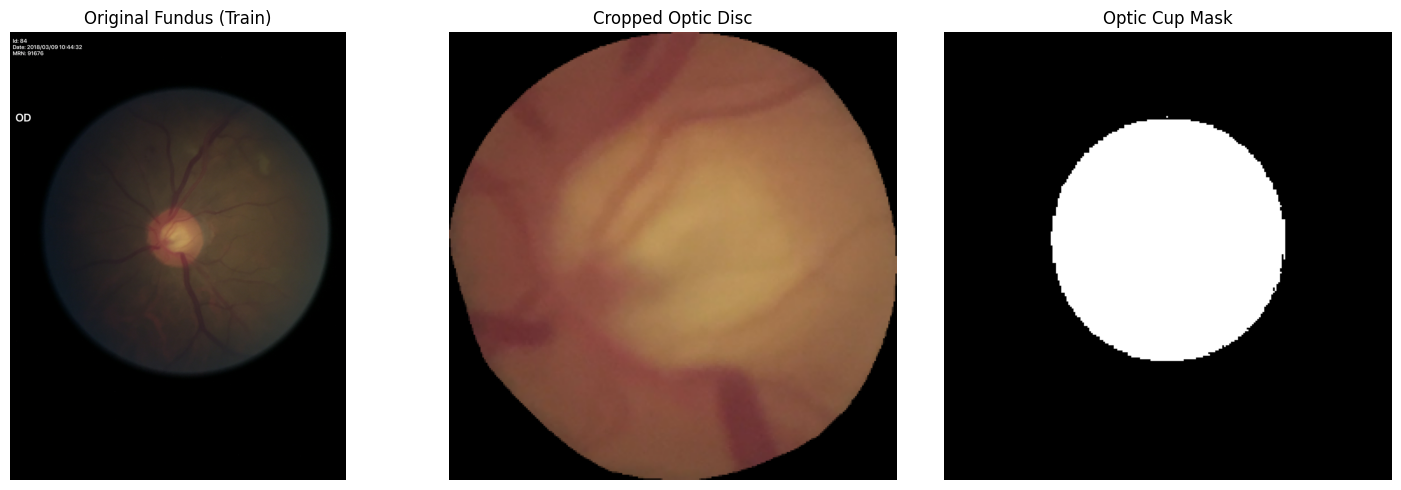


✅ Cropped Image shape: (256, 256, 3)
✅ Cup Mask shape: (256, 256)
✅ Cup unique values: [  0 255]
✅ Cup area: 14601 pixels


In [12]:
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu-train/Train'
test_camera = 'Remidio'
test_image_name = '18499'  # or 'IMG_2439'

# Auto-detect image extension
test_image_path = None
for ext in ['.jpg', '.JPG', '.jpeg', '.png', '.tif', '.bmp']:
    potential_path = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images', test_camera, f"{test_image_name}{ext}")
    if os.path.exists(potential_path):
        test_image_path = potential_path
        print(f"Found image: {test_image_path}")
        break

if test_image_path is None:
    print(f"❌ Image not found: {test_image_name} in {test_camera}")
else:
    print(f"✅ Image exists: {test_image_path}")
    print(f"\n🔍 Searching for mask in: Expert 5, Mean, Median, STAPLE")
    
    # Get combined mask for Train (searches all locations)
    combined_disc_mask, combined_cup_mask = get_combined_mask_train(test_image_name, test_camera, INPUT_PATH)
    
    if combined_disc_mask is not None and combined_cup_mask is not None:
        # Read image
        image = cv2.imread(test_image_path)
        
        if image is not None:
            # Resize to match
            image, combined_disc_mask = resize_to_match(image, combined_disc_mask)
            _, combined_cup_mask = resize_to_match(image, combined_cup_mask)
            
            # Apply function
            cropped_image, cup_mask = get_roi_and_oc_mask_chakshu(image, combined_disc_mask, combined_cup_mask)
            
            # Display results
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original
            original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            axes[0].imshow(original_rgb)
            axes[0].set_title('Original Fundus (Train)')
            axes[0].axis('off')
            
            # Cropped image
            cropped_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
            axes[1].imshow(cropped_rgb)
            axes[1].set_title('Cropped Optic Disc')
            axes[1].axis('off')
            
            # Cup mask
            axes[2].imshow(cup_mask, cmap='gray')
            axes[2].set_title('Optic Cup Mask')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n✅ Cropped Image shape: {cropped_image.shape}")
            print(f"✅ Cup Mask shape: {cup_mask.shape}")
            print(f"✅ Cup unique values: {np.unique(cup_mask)}")
            print(f"✅ Cup area: {np.sum(cup_mask > 0)} pixels")
        else:
            print(f"Failed to read image: {test_image_path}")
    else:
        print(f"❌ Mask not found for: {test_image_name}")

**Cell 4: Batch Processing for all images**

In [13]:
# Batch process all Train images (searches all mask locations)
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu-train/Train'
OUTPUT_PATH = '/kaggle/working/CHAKSHU_Train_Processed'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Create fundus and masks subfolders
fundus_output = os.path.join(OUTPUT_PATH, 'fundus')
masks_output = os.path.join(OUTPUT_PATH, 'masks')
os.makedirs(fundus_output, exist_ok=True)
os.makedirs(masks_output, exist_ok=True)

# Cameras (Train has Remidio, but keeping flexible)
cameras = ['Remidio']

stats = {}

print("="*60)
print("PROCESSING CHAKSHU TRAIN DATASET")
print(f"Searching mask locations: Expert 5, Mean, Median, STAPLE")
print("="*60)

for camera in cameras:
    images_dir = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images', camera)
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {camera} - images not found")
        continue
    
    # Get all images
    image_files = []
    for f in os.listdir(images_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif')):
            image_files.append(f)
    
    print(f"\n📁 Processing {camera} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Get combined mask (searches all locations)
            combined_disc_mask, combined_cup_mask = get_combined_mask_train(img_name, camera, INPUT_PATH)
            
            if combined_disc_mask is None or combined_cup_mask is None:
                continue
            
            # Read image
            image = cv2.imread(img_path)
            
            if image is None:
                continue
            
            # Resize to match
            image, combined_disc_mask = resize_to_match(image, combined_disc_mask)
            _, combined_cup_mask = resize_to_match(image, combined_cup_mask)
            
            # Apply function
            cropped_image, cup_mask = get_roi_and_oc_mask_chakshu(image, combined_disc_mask, combined_cup_mask)
            
            # Save
            output_img_path = os.path.join(fundus_output, f"{camera}_{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            output_mask_path = os.path.join(masks_output, f"{camera}_{img_name}.png")
            cv2.imwrite(output_mask_path, cup_mask)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[camera] = success
    print(f"  ✅ {camera}: {success} images")

# Create ZIP file
zip_path = '/kaggle/working/CHAKSHU_Train_Processed.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

print("\n📁 Output Structure:")
print("  CHAKSHU_Train_Processed/")
print("    ├── fundus/  (all cropped optic discs)")
print("    └── masks/   (all cup masks)")

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
for camera, count in stats.items():
    print(f"  ✅ {camera}: {count} images processed")
print(f"\nTotal: {sum(stats.values())} images")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING CHAKSHU TRAIN DATASET
Searching mask locations: Expert 5, Mean, Median, STAPLE

📁 Processing Remidio - 185 images


  2%|▏         | 3/185 [00:00<00:10, 17.95it/s]

  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/Median/IMG_2480.png
  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/Mean/IMG_3533.tif


  4%|▍         | 7/185 [00:00<00:13, 13.17it/s]

  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Expert 5/Remidio/IMG_2574.tif
  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/STAPLE/IMG_2454.png


...

 98%|█████████▊| 181/185 [00:20<00:00,  7.93it/s]

  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/Mean/IMG_3521.tif
  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/Median/IMG_2499.png


100%|██████████| 185/185 [00:21<00:00,  8.75it/s]


  Found mask: /kaggle/input/datasets/mrunal0501/chakshu-train/Train/4.0_OD_CO_Fusion_Images/Remidio/Mean/IMG_3668.tif
  ✅ Remidio: 127 images

✅ ZIP created: /kaggle/working/CHAKSHU_Train_Processed.zip
📊 Size: 2.02 MB

📁 Output Structure:
  CHAKSHU_Train_Processed/
    ├── fundus/  (all cropped optic discs)
    └── masks/   (all cup masks)

FINAL SUMMARY
  ✅ Remidio: 127 images processed

Total: 127 images


/kaggle/working/CHAKSHU_Train_Processed.zip